### Assignment1: Exploratory Data Analysis of a Portuguese banking institution

Source: https://archive.ics.uci.edu/dataset/222/bank+marketing

Author: Chi Hang (Philip) Cheung

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mlxtend.plotting import scatterplotmatrix
import math
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

1) #### Review the structure and content of the data and answer questions such as:
    a) Are the features (columns) of your data correlated?

    b) What is the overall distribution of each variable?

    c) Are there any outliers present?

    d) What are the relationships between different variables?

    e) How are categorical variables distributed?

    f) Do any patterns or trends emerge in the data?

    g) What is the central tendency and spread of each variable?

    h) Are there any missing values and how significant are they? 

In [130]:
df = pd.read_csv('bank-full.csv', sep=';')
df.head()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


#### a: Are the features of the data correlated?

Computing numerical columns for correlations only:

There seems to be hardly any correlations between numerical variables according to the graph.

To get an overview of all categorical and numerical association, we can use the dython package.

It automatically detects the data type of the column to decide which column needs categorical or numerical computation.

**Ans: poutcome and pday seem to have the strongest association value = 0.88 while the rest of the features do not share too much associations.
Even if the target variable 'y' does not seem like showing any kind of association with any of the features.**

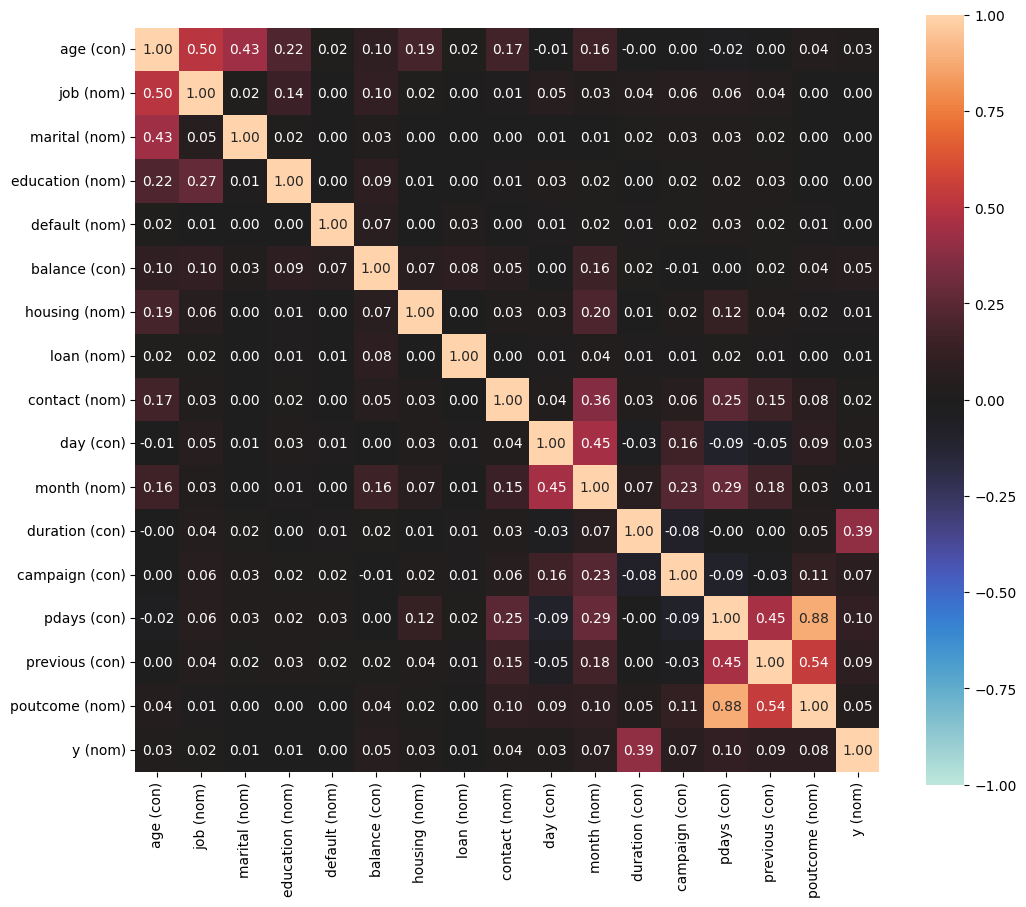

{'corr':                  age (con)  job (nom)  marital (nom)  education (nom)  \
 age (con)         1.000000   0.501129       0.433431         0.215201   
 job (nom)         0.501129   1.000000       0.020650         0.144927   
 marital (nom)     0.433431   0.047969       1.000000         0.017695   
 education (nom)   0.215201   0.274198       0.014412         1.000000   
 default (nom)     0.017879   0.007442       0.001905         0.001443   
 balance (con)     0.097783   0.101776       0.028172         0.087657   
 housing (nom)     0.185513   0.059796       0.000311         0.010349   
 loan (nom)        0.015655   0.015767       0.003170         0.007885   
 contact (nom)     0.170555   0.025310       0.002540         0.018489   
 day (con)        -0.009120   0.047611       0.007723         0.025965   
 month (nom)       0.160218   0.030960       0.002558         0.008730   
 duration (con)   -0.004648   0.040774       0.023110         0.003806   
 campaign (con)    0.004760   

In [131]:
#Here is a quick method to compare all the numerical and categorical features using respective correlation methods:
#Numerical vs numerical = Pearson
#Categorical vs categorical = Theil's U
#Categorical vs numerical = Correlation Ratio
from dython.nominal import associations
associations(df, nom_nom_assoc='theil', plot=True, figsize=(12,10), mark_columns=True)


b) What is the overall distribution of each variable?

**Ans: Most of the numerical features seem to have a right skewed tendency.
We may standardize the datapoints if needed to improve the model quality**

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'pdays'}>],
       [<Axes: title={'center': 'previous'}>, <Axes: >, <Axes: >]],
      dtype=object)

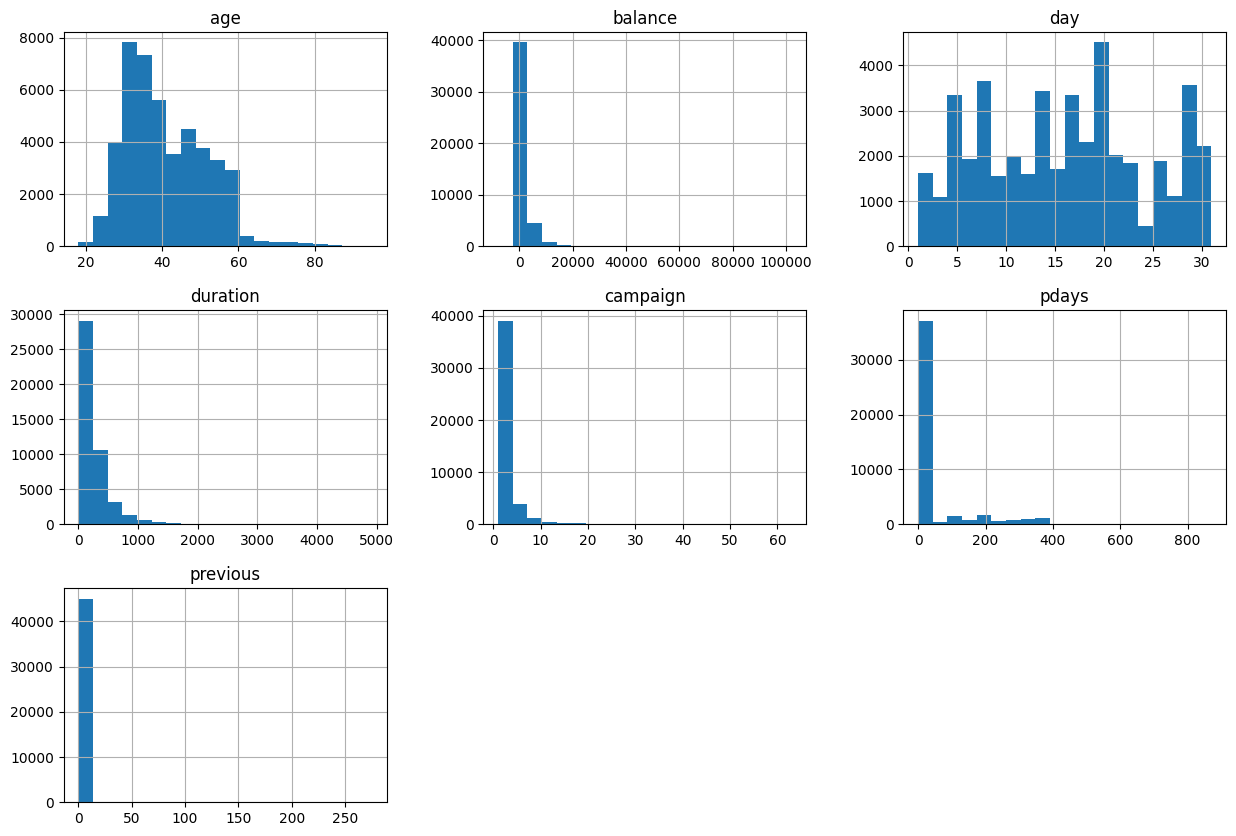

In [132]:
#Showing histograms for numeric features:
df_num = df.select_dtypes(include=[np.number])
df_num.hist(bins=20, figsize=(15, 10), layout=(3, 3))

Distribution of the categorical data:

**Ans: May - August are the busiest months to contact the clients according to the histograms.
In addition, enterpeneurs and managements are the most focused groups to call.**

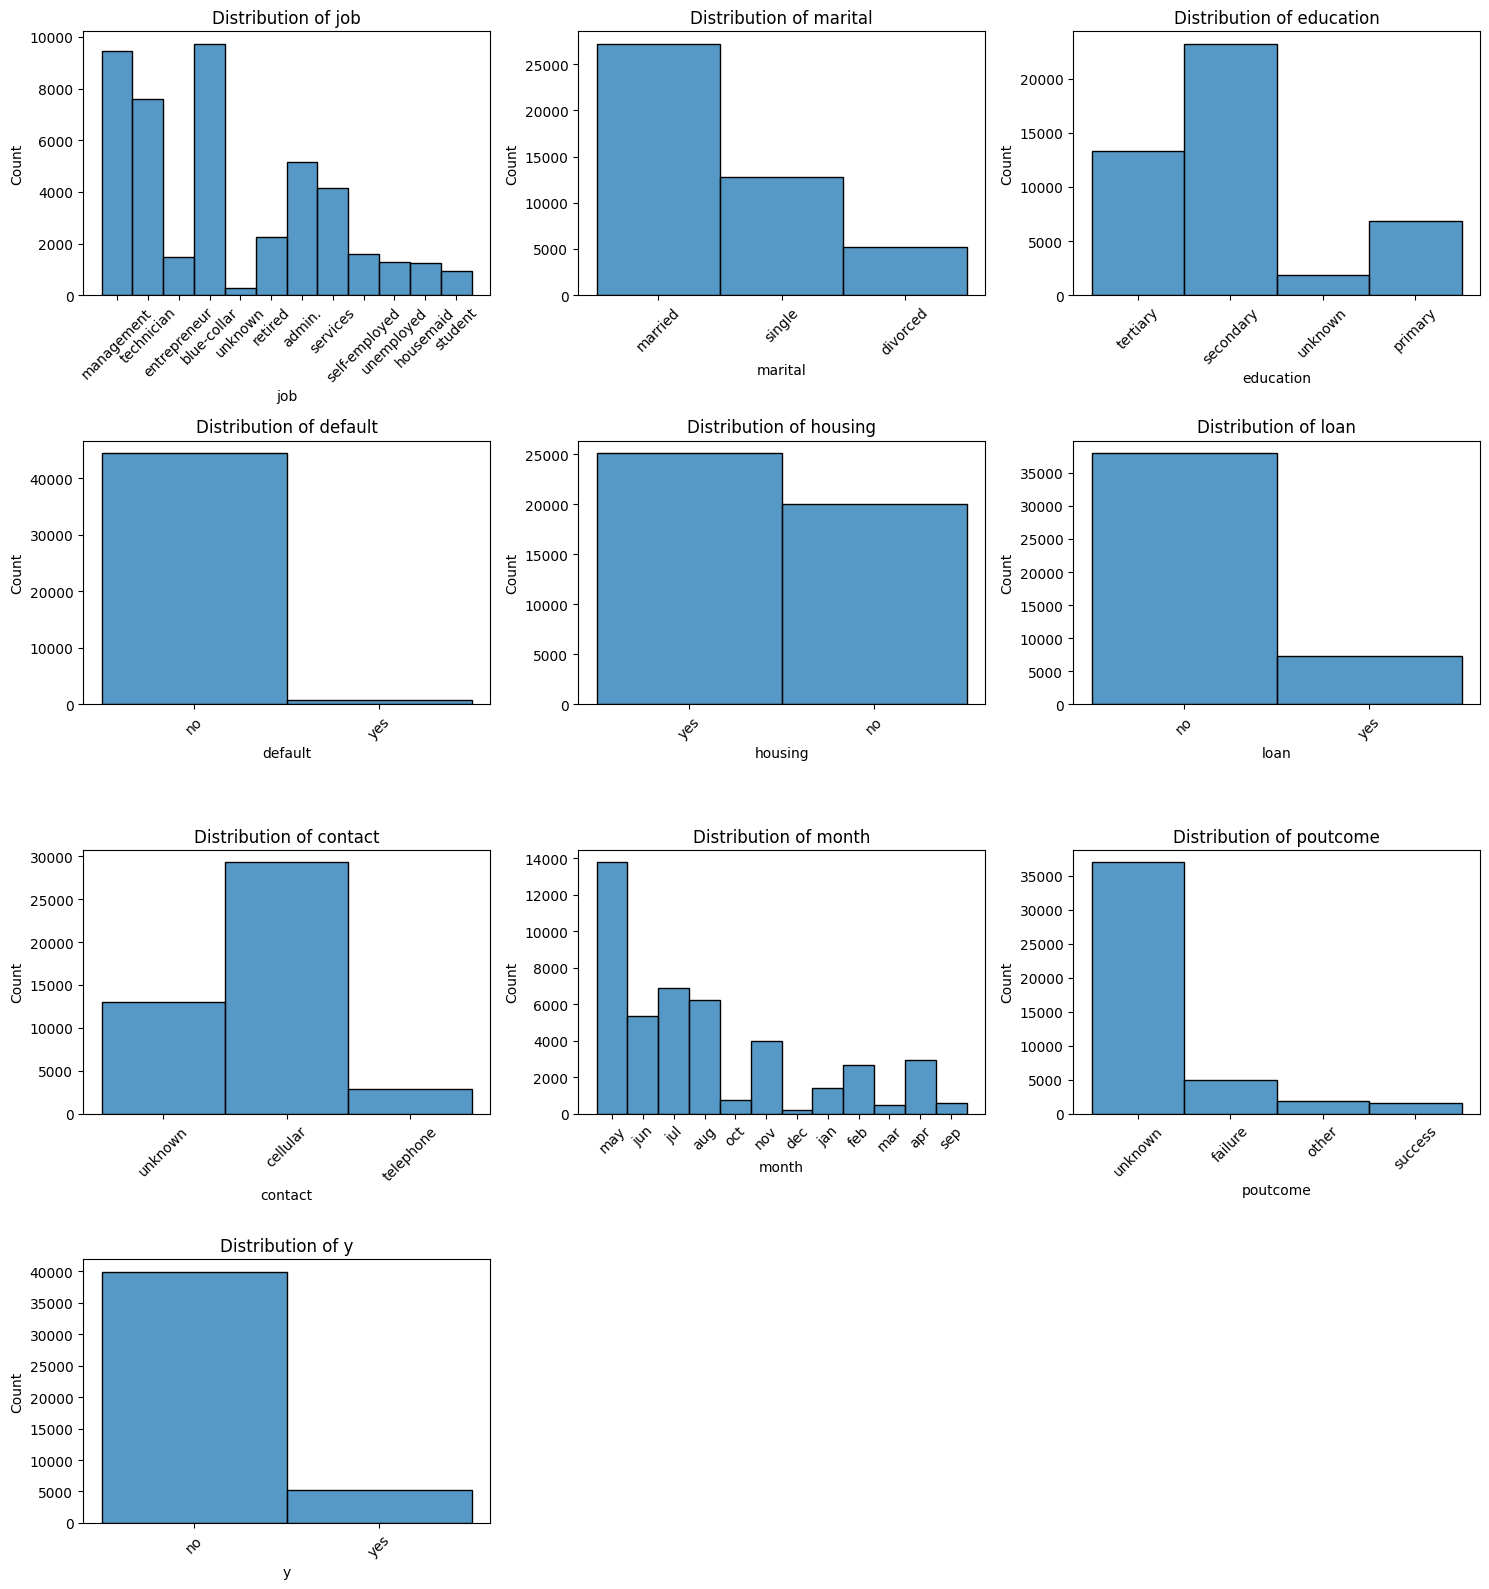

In [133]:
#Distribution of the categorical features:
df_cat = df.select_dtypes(include=['object'])
#Histrograms for categorical features:
ncols = 3
nrows = math.ceil(len(df_cat.columns)/ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(df_cat.columns):
    sns.histplot(data = df_cat, x=col, kde=False, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

#Remove empty plots:
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

c) Are there any outliers present?

**Ans: Yes, There are many in each numerical columns. They are highlighted in red circles.**

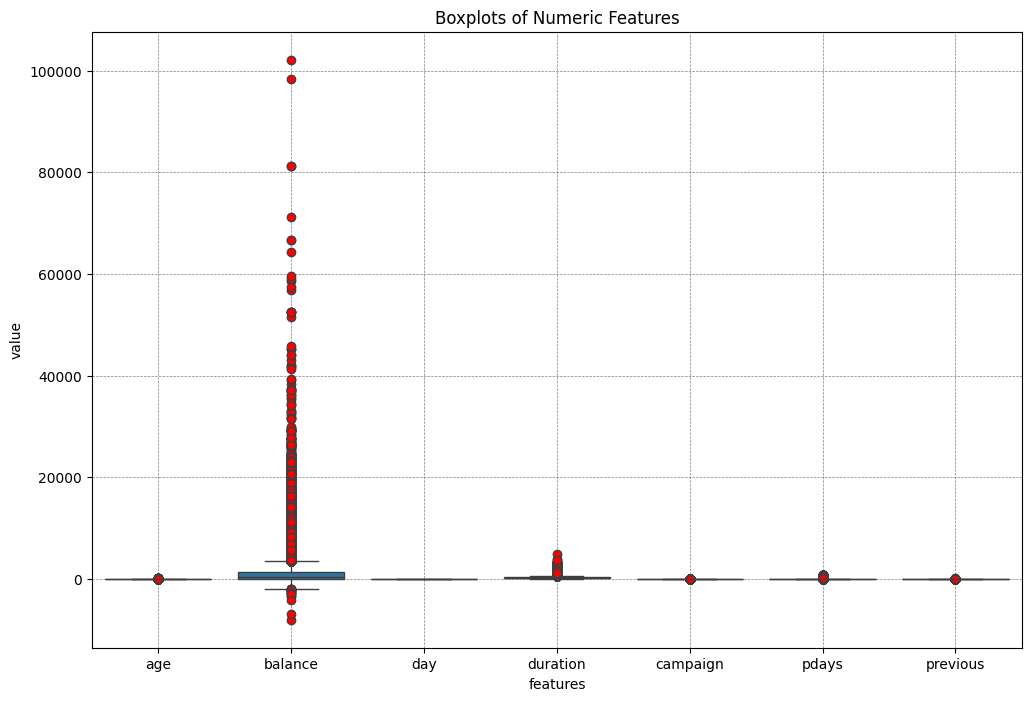

In [134]:
df_num_long = pd.melt(df_num, var_name='features', value_name='value')
plt.figure(figsize=(12, 8))

flierprops = dict(marker='o', markerfacecolor='red', markersize=6, linestyle='none')
sns.boxplot(data = df_num_long,
            x='features',
            y='value',
            flierprops=flierprops
            )
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.title('Boxplots of Numeric Features')
plt.show()



d) What are the relationships between different variables?

**Ans: According to the association plot above, many of the variables do not show a strong association with one another except for poutcome and pdays.**

**If we examine the poutcome vs pdays box plot below, we can see that the success cases from the previous campaign correlates strongly in a shorter, more frequent calling of those clients as indicated by the shorter mean pdays.**

Text(0.5, 1.0, 'Boxplot of pdays by poutcome')

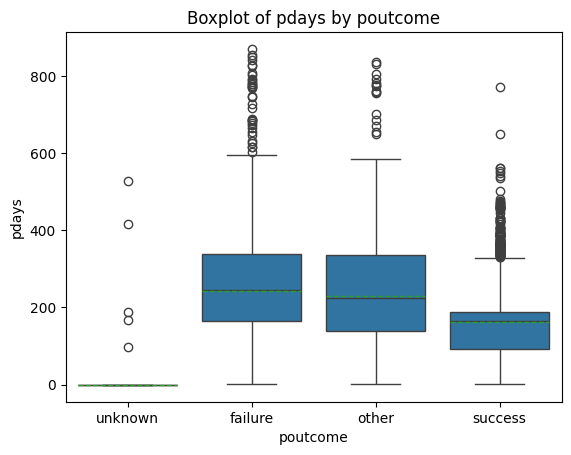

In [135]:
sns.boxplot(x='poutcome',
            y='pdays',
            data=df,
            meanline=True,
            showmeans=True)
plt.title('Boxplot of pdays by poutcome')

e) How are categorical variables distributed?

**Ans: As mentioned above, many of the contacted groups are from management and business ends. Roughly only 9% of the calls resulted in a successful subscription to the bank's service. Majority of the clients contacted were married with secondary education and most importantly most of the clients do not have personal loans. These distributions made sense from a business standpoint because people without loans, married, with management or business professions are more likely to have extra income to subcribe to the bank's services for deposit rather than those who are short in income.**

   

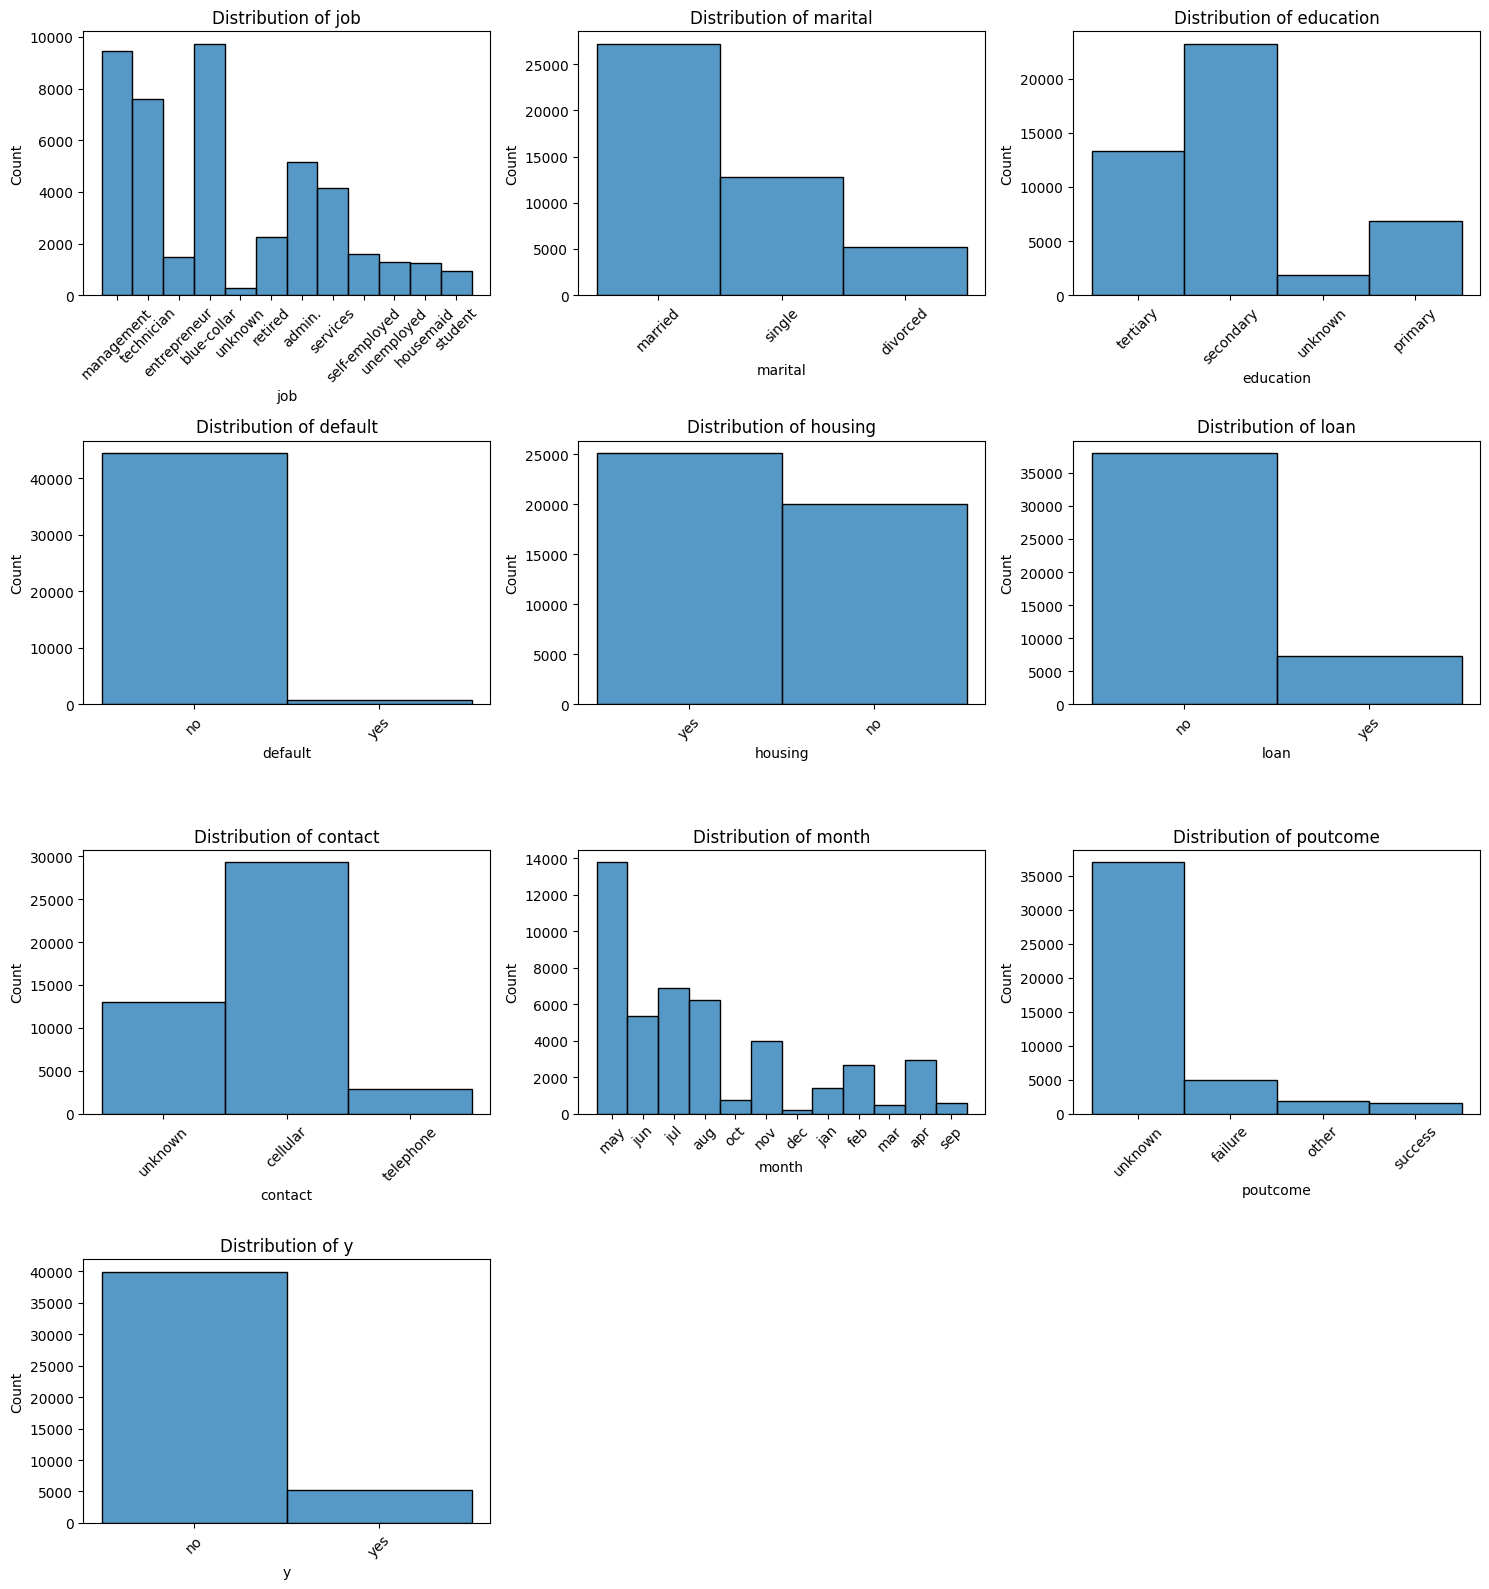

In [136]:
#Distribution of the categorical features:
df_cat = df.select_dtypes(include=['object'])
#Histrograms for categorical features:
ncols = 3
nrows = math.ceil(len(df_cat.columns)/ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(df_cat.columns):
    sns.histplot(data = df_cat, x=col, kde=False, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

#Remove empty plots:
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

f) Do any patterns or trends emerge in the data?

**Ans: There seems to be an inverse growth trend in 'balance vs duration', 'balance vs campaign', 'duration vs campaign' and ' campaign vs pdays'**


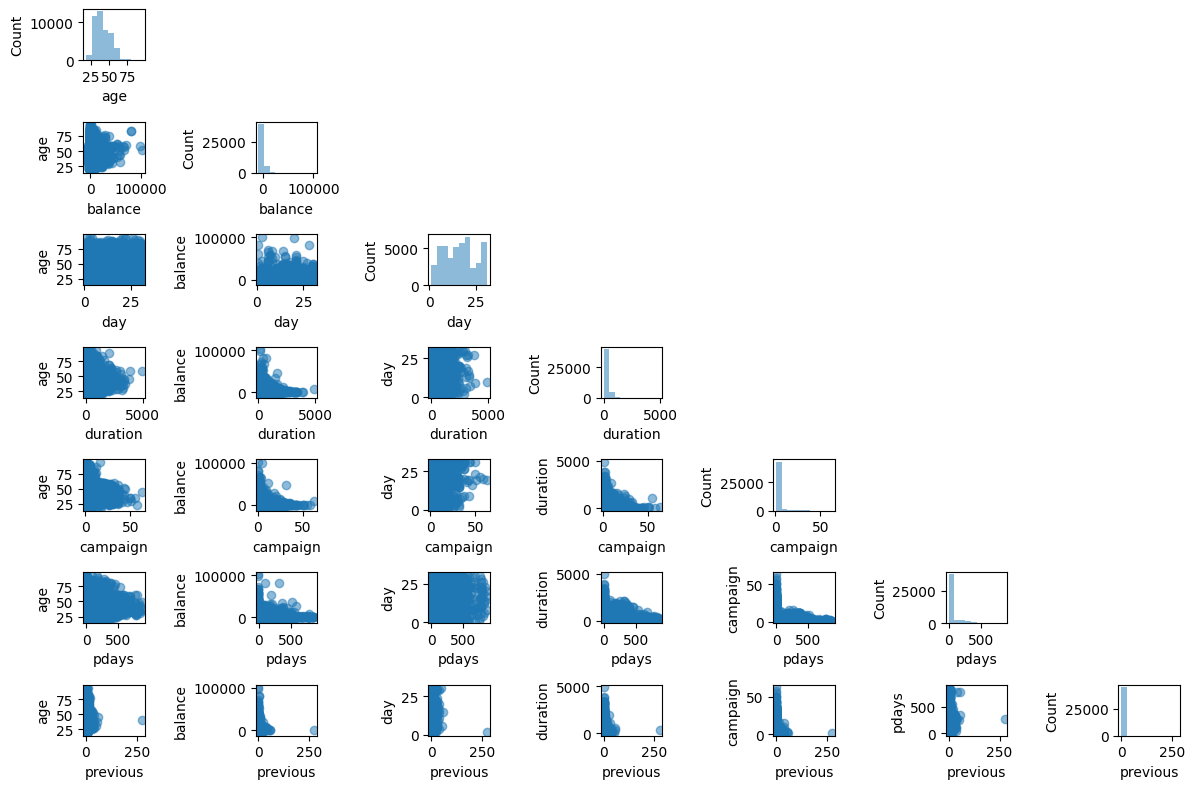

In [137]:
#Scatter plot matrix for numeric features:
scatterplotmatrix(df_num.values, figsize=(12, 8), names=df_num.columns, alpha=0.5)
plt.tight_layout()

g) What is the central tendency and spread of each variable?

**Ans: The central tendency of the numerical data are right skewed. In particular, the 'balance' column has a very wide spread of datapoints--STD is over 3000. The '-1' value from pdays was left unmodified to allow for numerical calculations. The stats of pdays might not be as important as it mostly signifies whether a client is a new client.**


In [138]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Categorical values counts.

In [139]:
df_cat.value_counts()

job          marital   education  default  housing  loan  contact   month  poutcome  y  
blue-collar  married   secondary  no       yes      no    unknown   may    unknown   no     721
management   married   tertiary   no       no       no    cellular  aug    unknown   no     657
blue-collar  married   primary    no       yes      no    unknown   may    unknown   no     642
technician   married   secondary  no       no       no    cellular  aug    unknown   no     420
management   single    tertiary   no       no       no    cellular  aug    unknown   no     346
                                                                                           ... 
admin.       divorced  secondary  no       no       no    cellular  apr    other     yes      1
                                                                    aug    failure   yes      1
                                                                           other     yes      1
                                               

h) Are there any missing values and how significant are they?

**Ans: There is no missing values.**

In [140]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

2) #### Algorithm Selection:

    Now you have completed the EDA, what Algorithms would suit the business purpose for the dataset. Answer questions such as:
    
    Select two or more machine learning algorithms presented so far that could be used to train a model

    (no need to train models - I am only looking for your recommendations).

    **Ans: I would choose LDA, L1 regularization, PCA (as a preprocessing step), and XGBoost as my choices. These were selected because the dataset has many features, some of which may not be predictive, so dimensionality reduction and robust supervised models are important.**

    What are the pros and cons of each algorithm you selected?

    **Ans:**

    **LDA Pros:** Supervised learning with dimensionality reduction that can help to reduce unimportant features.

    **LDA Cons:** it assumes linearity boundary and multivariate normality within the features. This is obviously not always the case in real-world data even in this dataset.

    **L1 regularization Pros:** it can reduce the weight of a features to 0 and effectively shrinks the feature set to only processing important ones. It is also computationally efficient and prevents overfitting.
    In addition, it is very interpretible to see which feature are less important.

    **PCA Pros:** It can transform the features into principle components to reduce the dimensionality.

    **PCA Cons:** It is a unsupervised ML technique not suitable to be a classifier for our purpose here. In addition, the transformed features loses their interpretbility.

    **XGBoost Pros:** it can handle categorical feature encoding as well as large dataset efficiently. This non-linear model generally yields better results than linear models since it can self-correct in each iteration.

    **XGBoost Cons:** In small datasets, XGBoost could become overfitted.

    Which algorithm would you recommend, and why?

    **Ans: I would recommend applying L1 regularization first to remove irrelevant features, then training an XGBoost classifier on the reduced feature set. This two-step strategy improves interpretability, reduces computational cost, and leverages the predictive strength of XGBoost.**

    Are there labels in your data? Did that impact your choice of algorithm?

    **Ans: Yes, my dataset has labels — the target variable 'y' indicates whether a customer subscribed to the campaign (yes/no). Since this is labeled data, the problem is a supervised learning classification task, which rules out the pure use of PCA. The presence of labels guides the choice of algorithm, because I can use supervised classifiers such as Logistic Regression, Random Forest, or XGBoost. In particular, XGBoost is well-suited here since it is a supervised classification algorithm that handles both numeric and categorical features effectively.**

    How does your choice of algorithm relates to the dataset?

    **Ans: My choices specifically address the challenges of this dataset: many features, weak correlations, and potential redundancy. From a business perspective, feature reduction not only improves model accuracy but also highlights which features are worth collecting in future campaigns, saving time and resources. Combining reduction with a strong classifier like XGBoost tailors the solution to both the data structure and business goals.**

    Would your choice of algorithm change if there were fewer than 1,000 data records, and why?

    **Ans: With fewer than 1,000 samples, I would still prioritize feature reduction but avoid complex models like XGBoost that risk overfitting. Simpler models such as Logistic Regression with L1 regularization or LDA would be better suited, since they generalize more reliably on small datasets.**

3) #### Pre-processing:
    
    Now you have done an EDA and selected an Algorithm, what pre-processing (if any) would you require for:

    Data Cleaning - improve data quality, address missing data, etc.

    Dimensionality Reduction - remove correlated/redundant data than will slow down training

    Feature Engineering - use of business knowledge to create new features

    Sampling Data - using sampling to resize datasets

    Data Transformation - regularization, normalization, handling categorical variables

    Imbalanced Data - reducing the imbalance between classes
    
    Deliverable


In [141]:
#Separate target from features:
y = df['y'].map({'yes':1, 'no':0})  #Encoding the target variable
x = df.drop(columns=['y'])

cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.drop('y')  #Exclude the target variable
num_cols = df.select_dtypes(include=[np.number]).columns

#Combine the transformers:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), num_cols), #Standardize numerical features
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols) #One-hot encode categorical features
    ]
)

#Logistic regression model with L1 regularization:
l1 = LogisticRegression(
    penalty='l1',
    solver='saga',
    max_iter=5000,
    C=0.1
)

#Pipeline for preprocessing:
pre_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('dim_reduction', l1)])


In [142]:
pre_pipeline.fit(x, y)
# Extract fitted OneHotEncoder feature names
ohe_feature_names = pre_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols)

# Combine with numeric cols
all_feature_names = np.concatenate([ohe_feature_names, num_cols])

# Coefficients from logistic regression
coefs = pre_pipeline.named_steps['dim_reduction'].coef_[0]

# Features where coef ≠ 0
selected_features = all_feature_names[coefs != 0]

print('Number of features before L1 regularization:', len(all_feature_names))
print("Number of selected features:", len(selected_features))


Number of features before L1 regularization: 51
Number of selected features: 36


Essay (minimum 500 words)
Write a short essay summarizing your findings. Explain your selection of algorithms and how they relate to the data and what you are trying to do.
Format: PDF

Of the datasets available from the source link, the full dataset containing over 40,000 samples and the complete set of predictors was selected for analysis. Since the goal is to explore the data structure and patterns behind the campaign’s success rate, leveraging a larger dataset should provide more reliable and generalizable results.

The dataset includes both numerical and categorical predictors, which were analyzed for their statistical associations using Pearson’s correlation (numerical vs. numerical), Theil’s U (categorical vs. categorical), and the correlation ratio (numerical vs. categorical). The strongest association was found between pdays (the number of days since the client was last contacted in a previous campaign) and poutcome (the outcome of the previous campaign). This relationship is logical: clients who subscribed previously were more likely to subscribe again and were contacted sooner than those who did not subscribe or had never subscribed. Apart from this, most predictors showed weak associations with each other and with the target variable, which represents whether the campaign succeeded. Additionally, several predictors displayed right skewness and contained outliers. To address these issues, transformations such as log-scaling or box-cox transformation could be applied where appropriate. However, since XGBoost is generally robust to outliers and skewedness, the main preprocessing focus remains on dimensionality reduction.

Given these exploratory findings and the presence of a labeled target variable, several supervised learning methods were considered, including Linear Discriminant Analysis (LDA), L1-regularized logistic regression, Principal Component Analysis (PCA as a preprocessing step), and XGBoost. After weighing the pros and cons, a hybrid strategy was proposed: first applying L1-regularized logistic regression for feature selection to filter out irrelevant predictors, followed by training an XGBoost classifier on the reduced set. This approach balances dimensionality reduction with predictive strength. Unlike PCA, which loses interpretability, L1-based feature reduction retains clarity about which predictors matter. XGBoost was chosen because it handles categorical encoding, works efficiently on large datasets, and typically achieves strong predictive performance without requiring strict data normalization.

In conclusion, the analysis shows that while most predictors individually contribute little to the target outcome, combining feature selection with a robust tree-based classifier provides an effective and practical solution. This two-step strategy balances interpretability, computational efficiency, and accuracy. From a business perspective, it also highlights which predictors are most valuable for future data collection, ensuring resources are focused where they can maximize the success of upcoming marketing campaigns.